In [ ]:
import marimo as mo

# Delta-Minimax Group Sequential Design via Bayesian Optimisation
## Option 2: Reverse Parameterisation (Joint Optimisation)

This notebook implements the reverse parameterisation approach described in
*Parameterisation of the delta-Minimax Group Sequential Design Problem* (Kirk & Abdelghany, 2026).

Rather than working in the original parameter space
$\theta = (n, l_1, u_1, \ldots, l_K, u_K)$ — where the vast majority of
Bayesian optimisation proposals violate the monotonicity constraints — we
reparameterise in terms of the **meeting point** $c = l_K = u_K$ and
**non-negative boundary increments** $\Delta u_k$, $\Delta l_k$. This
guarantees that every proposed design satisfies the structural constraints by
construction, requiring no rejection sampling, no monotonicity penalty, and no
failure region classifier.

The reverse parameterisation for $K$ stages is:
$$
    u_k = c + \sum_{j=k+1}^{K} \Delta u_j, \qquad
    l_k = c - \sum_{j=k+1}^{K} \Delta l_j,
$$
with $u_K = l_K = c$ exactly. The BO parameter vector is
$\tilde{\theta} = (n,\, c,\, \Delta u_K, \Delta l_K, \ldots, \Delta u_2, \Delta l_2)$.

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
import gpflow
import trieste
from trieste.space import Box
from trieste.models.gpflow.models import GaussianProcessRegression

/opt/venv/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
from py_group_sequential_designs import generate_boundaries as bd
from py_group_sequential_designs import feasibility_penalty as fp
from py_group_sequential_designs import function_to_minimize as fn_min
from py_group_sequential_designs import simulate as sim
from py_group_sequential_designs import sample_size as ss

# Trial Design Settings

Settings match Mazin's existing runs for direct comparability.

In [ ]:
num_analyses   = 3      # K: number of stages
target_alpha   = 0.05   # alpha*: required type I error
target_power   = 0.9    # 1 - beta*: required power
delta1         = 1.0    # clinically relevant difference
sigma2         = 3.0    # assumed outcome variance

# single-stage sample size: used as penalty scaling (mu) and upper bound on n
mu = ss.sample_size_means(
    ratio    = 1,
    variance = sigma2,
    power    = target_power,
    alpha    = target_alpha,
    delta    = delta1
)

print(f"Single-stage sample size mu = {mu:.2f}")

Single-stage sample size mu = 154.15


# Reverse Parameterisation

Two utility functions handle the conversion between the BO parameter vector
$\tilde{\theta} = (n, c, \Delta u_K, \Delta l_K, \ldots, \Delta u_2, \Delta l_2)$
and the original boundary representation $(n, \{l_k, u_k\})$.

The BO vector is ordered with the **largest-stage increments first**, so that
the first increment parameters correspond to the final stage boundaries and the
last to the first-stage boundaries.

In [ ]:
def reverse_to_boundaries(params, K):
    """
    Convert a reverse-parameterisation BO vector to (n, upper_bounds, lower_bounds).

    Parameters
    ----------
    params : array-like, shape (2K,)
        [n, c, delta_u_K, delta_l_K, delta_u_{K-1}, delta_l_{K-1}, ..., delta_u_2, delta_l_2]
    K : int
        Number of stages.

    Returns
    -------
    n : float
        Patients per arm per stage.
    upper_bounds : ndarray, shape (K,)
        Efficacy boundaries u_1, ..., u_K.
    lower_bounds : ndarray, shape (K,)
        Futility boundaries l_1, ..., l_K.
    """
    params = np.asarray(params).flatten()
    n = params[0]
    c = params[1]

    # increments are interleaved: delta_u_K, delta_l_K, delta_u_{K-1}, ...
    delta_u = params[2::2]   # delta_u_K, delta_u_{K-1}, ..., delta_u_2
    delta_l = params[3::2]   # delta_l_K, delta_l_{K-1}, ..., delta_l_2

    # reverse so index 0 = stage 2 increment, ..., index K-2 = stage K increment
    delta_u = delta_u[::-1]  # now: delta_u_2, ..., delta_u_K
    delta_l = delta_l[::-1]  # now: delta_l_2, ..., delta_l_K

    # u_k = c + sum_{j=k+1}^{K} delta_u_j
    # l_k = c - sum_{j=k+1}^{K} delta_l_j
    upper_bounds = np.empty(K)
    lower_bounds = np.empty(K)

    for k in range(K):
        upper_bounds[k] = c + np.sum(delta_u[k:])   # sum from k+1 to K
        lower_bounds[k] = c - np.sum(delta_l[k:])

    return n, upper_bounds, lower_bounds


def boundaries_to_reverse(n, upper_bounds, lower_bounds):
    """
    Convert (n, upper_bounds, lower_bounds) to a reverse-parameterisation BO vector.
    Assumes the design already satisfies monotonicity and l_K == u_K.

    Parameters
    ----------
    n : float
    upper_bounds : array-like, shape (K,)
    lower_bounds : array-like, shape (K,)

    Returns
    -------
    params : ndarray, shape (2K,)
        [n, c, delta_u_K, delta_l_K, ..., delta_u_2, delta_l_2]
    """
    upper_bounds = np.asarray(upper_bounds)
    lower_bounds = np.asarray(lower_bounds)
    K = len(upper_bounds)

    c = upper_bounds[-1]  # = lower_bounds[-1] = meeting point

    # compute increments from final stage backwards
    # delta_u_k = u_{k-1} - u_k  for k = 2, ..., K  (decrement)
    # delta_l_k = l_k - l_{k-1}  for k = 2, ..., K  (increment)
    delta_u = np.diff(upper_bounds[::-1])   # u_K - u_{K-1}, ..., u_2 - u_1 (all >= 0)
    delta_l = np.diff(lower_bounds)          # l_2 - l_1, ..., l_K - l_{K-1} (all >= 0)

    # reverse delta_l so both are ordered K, K-1, ..., 2
    delta_l = delta_l[::-1]

    # interleave: [delta_u_K, delta_l_K, delta_u_{K-1}, delta_l_{K-1}, ...]
    increments = np.empty(2*(K-1))
    increments[0::2] = delta_u
    increments[1::2] = delta_l

    return np.concatenate([[n, c], increments])

In [ ]:
# sanity check: round-trip should recover original boundaries
_n_test  = 22.0
_upper   = np.array([2.12, 1.87, 1.84])
_lower   = np.array([0.0,  1.12, 1.84])

_params  = boundaries_to_reverse(_n_test, _upper, _lower)
_n2, _u2, _l2 = reverse_to_boundaries(_params, K=3)

print("Original upper:", _upper)
print("Recovered upper:", np.round(_u2, 6))
print("Original lower:", _lower)
print("Recovered lower:", np.round(_l2, 6))
print("n:", _n_test, "->", _n2)
print("Params:", np.round(_params, 6))

Original upper: [2.12 1.87 1.84]
Recovered upper: [2.12 1.87 1.84]
Original lower: [0.   1.12 1.84]
Recovered lower: [0.   1.12 1.84]
n: 22.0 -> 22.0
Params: [22.    1.84  0.03  0.72  0.25  1.12]


# Objective Function

The penalised objective is:

$$
f(\tilde{\theta}) = \frac{\max_\delta E[N \mid \delta]}{\mu} + \mu(\alpha' - \alpha^*)^2 + \mu(\beta' - \beta^*)^2
$$

using the smooth quadratic penalty from Mazin's existing code. Because all proposals
in the reverse parameterisation are structurally valid, there is no monotonicity check
and no fixed penalty of 25.

In [ ]:
def objective(params, mu, target_power, target_alpha, K):
    """
    Evaluate the penalised delta-minimax objective for a reverse-parameterisation
    BO vector.

    Parameters
    ----------
    params : array-like, shape (2K,)
        BO parameter vector in reverse parameterisation.
    mu : float
        Single-stage sample size (penalty scaling).
    target_power : float
        Required power 1 - beta*.
    target_alpha : float
        Required type I error alpha*.
    K : int
        Number of stages.

    Returns
    -------
    x : ndarray, shape (1, 2K)
        Input vector for Trieste dataset.
    y : ndarray, shape (1, 1)
        Objective value.
    """
    params = np.asarray(params).flatten()

    # convert to original boundary representation
    n, upper_bounds, lower_bounds = reverse_to_boundaries(params, K)

    # simulate trial to get alpha' and power
    trial = sim.group_sequential_designs(
        n_analyses   = K,
        upper_bounds = upper_bounds,
        lower_bounds = lower_bounds,
        n_patients   = n,
        null_hypothesis = 0,
        alt_hypothesis  = delta1,
        variance        = sigma2
    )

    alpha_prime = trial[1]
    power_prime = trial[2]
    beta_prime  = 1 - power_prime

    # compute maximum expected sample size
    max_ess = ss.max_ess(
        n_analyses   = K,
        upper_bounds = upper_bounds,
        lower_bounds = lower_bounds,
        n_patients   = n,
        null_hypothesis = 0,
        variance        = sigma2
    )

    # smooth penalty: penalises error constraint violations quadratically
    penalty = fp.smooth_penalty(
        mu          = mu,
        power       = target_power,
        alpha       = target_alpha,
        beta_prime  = beta_prime,
        alpha_prime = alpha_prime
    )

    y = fn_min.function_to_minimize(
        max_ess_val = max_ess / mu,
        penalty     = penalty
    )

    # clip to prevent huge penalty spikes dominating the GP surrogate
    # feasible designs are ~0.27-0.40, so 2.0 is a generous upper bound
    y = float(np.clip(y, 0, 2.0))

    return np.array([params]), np.array([[y]])

# Initialisation

We use a two-part initialisation strategy:

1. **Perturbations around known designs** — 5 small perturbations around each
of the Pocock, O'Brien-Fleming, and triangular designs. These are likely to be
feasible and give the GP good local coverage near regions of interest.

2. **Random feasible points** — a large pool of uniform random candidates is
generated and evaluated; only those with objective < 2.0 (i.e. not hitting the
clip) are retained. This gives broader global coverage of the feasible region.

The triangular design itself is **not** included — it is computed only for
search space centering and as a benchmark.

In [ ]:
# compute triangular design for search space centering and benchmark only
# returned as tri_params and c0 for use by subsequent cells
_tri = bd.calculate_triangular_boundaries(
    n_analyses = num_analyses, alpha = target_alpha,
    delta = delta1, n_patients = 20
)
_tri_n, _ = ss.find_sample_size(
    n_analyses = num_analyses, upper_bounds = _tri[0], lower_bounds = _tri[1],
    alt_hypothesis = delta1, variance = sigma2
)
tri_params = boundaries_to_reverse(_tri_n, _tri[0], _tri[1])
c0         = tri_params[1]   # meeting point: centre for search space and random sampling

_tri_obj = objective(tri_params, mu, target_power, target_alpha, num_analyses)[1][0, 0]
print(f"Triangular benchmark objective: {_tri_obj:.4f}")
print(f"Triangular params: {np.round(tri_params, 4)}")
print(f"Meeting point c0 = {c0:.4f}")

Triangular benchmark objective: 0.2715
Triangular params: [21.3212  1.8356  0.0379  0.7115  0.2461  1.1241]
Meeting point c0 = 1.8356


In [ ]:
rng_init = np.random.default_rng(seed=42)

# --- compute Pocock and O'Brien-Fleming reference designs ---
poc = bd.calculate_pocock_boundaries(
    n_analyses = num_analyses, alpha = target_alpha, n_patients = 20
)
poc_n, _ = ss.find_sample_size(
    n_analyses = num_analyses, upper_bounds = poc[0], lower_bounds = poc[1],
    alt_hypothesis = delta1, variance = sigma2
)
poc_params = boundaries_to_reverse(poc_n, poc[0], poc[1])

obf = bd.calculate_of_boundaries(
    n_analyses = num_analyses, alpha = target_alpha, n_patients = 20
)
obf_n, _ = ss.find_sample_size(
    n_analyses = num_analyses, upper_bounds = obf[0], lower_bounds = obf[1],
    alt_hypothesis = delta1, variance = sigma2
)
obf_params = boundaries_to_reverse(obf_n, obf[0], obf[1])

# --- part 1: perturbations around known designs ---
n_per_design     = 5
perturb_scale    = 0.15
reference_params = [poc_params, obf_params, tri_params]
ref_labels       = ["Pocock", "O'Brien-Fleming", "Triangular"]

perturb_x, perturb_y = [], []
for _ref, _label in zip(reference_params, ref_labels):
    for _ in range(n_per_design):
        _p     = _ref + rng_init.normal(scale=perturb_scale, size=len(_ref))
        _p[0]  = np.clip(_p[0],  2.0, mu)    # n >= 2
        _p[2:] = np.clip(_p[2:], 0.0, 4.0)   # increments non-negative
        _x, _y = objective(_p, mu, target_power, target_alpha, num_analyses)
        perturb_x.append(_x)
        perturb_y.append(_y)

n_feasible_perturb = sum(1 for _y in perturb_y if _y[0, 0] < 2.0)
print(f"Perturbation points: {len(perturb_y)} total, "
      f"{n_feasible_perturb} feasible")

# --- part 2: random feasible points from large pool ---
n_target  = 15    # target number of feasible random points
n_batch   = 1000  # pool size to sample from

candidates = np.column_stack([
    rng_init.uniform(2.0,    mu,       n_batch),
    rng_init.uniform(c0-1.5, c0+1.5,  n_batch),
    rng_init.uniform(0.0,    2.0,      n_batch),
    rng_init.uniform(0.0,    2.0,      n_batch),
    rng_init.uniform(0.0,    2.0,      n_batch),
    rng_init.uniform(0.0,    2.0,      n_batch),
])

random_x, random_y = [], []
n_evaluated = 0
for _p in candidates:
    _x, _y = objective(_p, mu, target_power, target_alpha, num_analyses)
    n_evaluated += 1
    if _y[0, 0] < 2.0:
        random_x.append(_x)
        random_y.append(_y)
    if len(random_x) >= n_target:
        break

print(f"Random feasible points: {len(random_x)} found "
      f"from {n_evaluated} candidates evaluated")

# --- combine ---
init_x = perturb_x + random_x
init_y = perturb_y + random_y

print(f"\nTotal initial points: {len(init_x)}")
print(f"Objective values: {[round(float(_y[0,0]), 4) for _y in init_y]}")

Perturbation points: 15 total, 15 feasible
Random feasible points: 15 found from 180 candidates evaluated

Total initial points: 30
Objective values: [0.4664, 0.3807, 0.6738, 0.3794, 0.3777, 0.3932, 0.4689, 0.3486, 0.3399, 0.3995, 0.3233, 0.2681, 0.2871, 0.2688, 0.3039, 1.4459, 1.5004, 1.2994, 0.8648, 1.5785, 1.5722, 1.5749, 0.7859, 1.651, 1.3851, 1.9779, 1.6922, 1.5214, 0.4118, 1.7673]


In [ ]:
design_matrix = np.concatenate(init_x)
output_vals   = np.concatenate(init_y)
print(f"Initial dataset: {design_matrix.shape[0]} points")

Initial dataset: 30 points


## Plot initial points

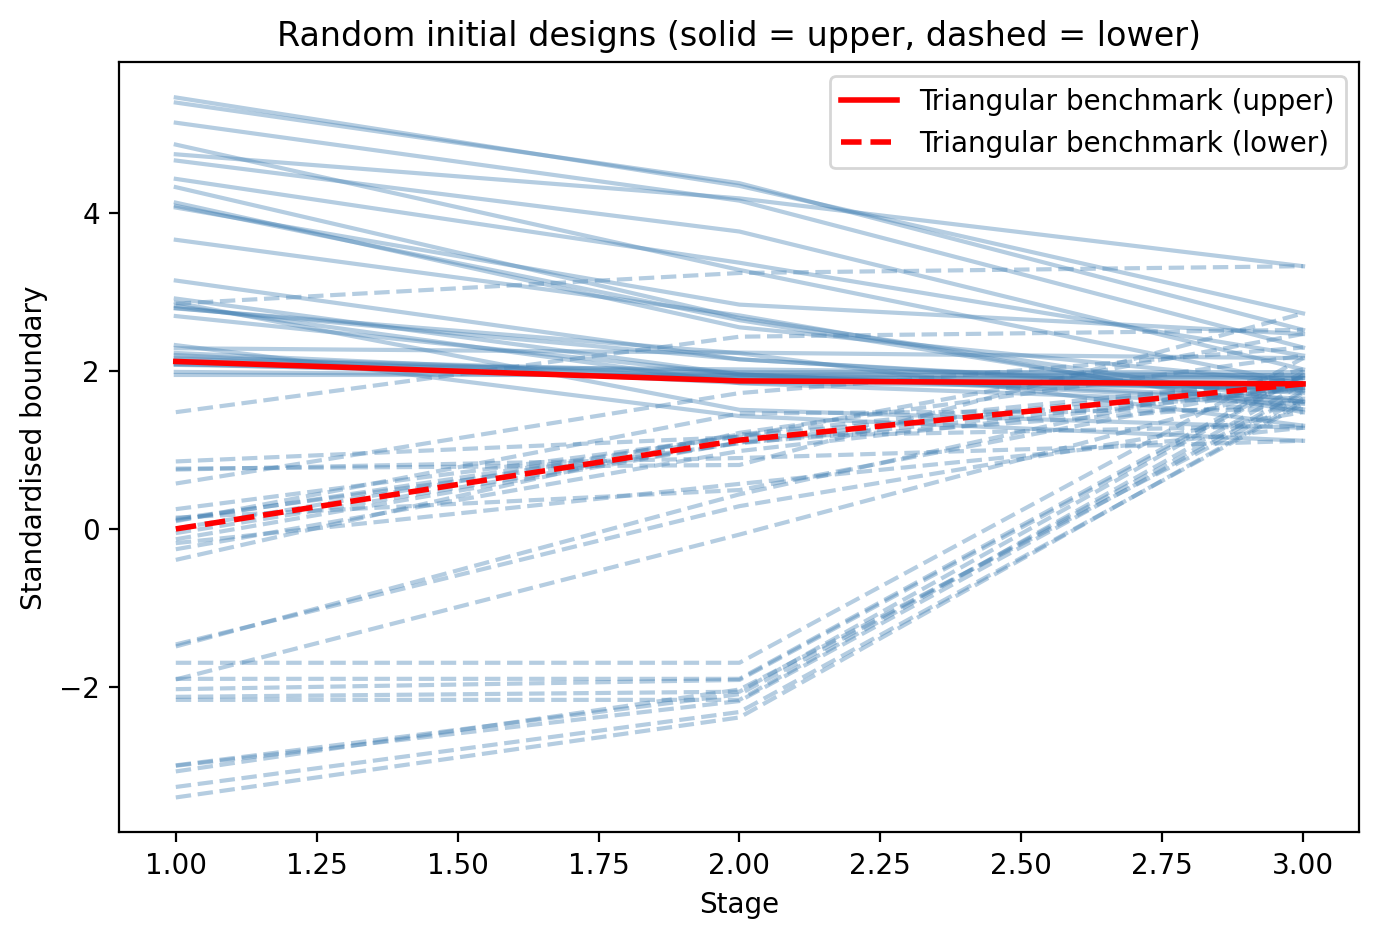

In [ ]:
_fig, _ax = plt.subplots(figsize=(8, 5))

for _i, _params in enumerate(design_matrix):
    _, _u, _l = reverse_to_boundaries(_params, K=3)
    _ax.plot([1, 2, 3], _u, color="steelblue", alpha=0.4)
    _ax.plot([1, 2, 3], np.concatenate((_l[:2], [_u[2]])),
             color="steelblue", alpha=0.4, linestyle="--")

# triangular benchmark for reference
_ax.plot([1, 2, 3], [2.1196, 1.8735, 1.8356], color="red",
         linewidth=2, label="Triangular benchmark (upper)")
_ax.plot([1, 2, 3], [0.0, 1.1241, 1.8356], color="red",
         linewidth=2, linestyle="--", label="Triangular benchmark (lower)")

_ax.set_xlabel("Stage")
_ax.set_ylabel("Standardised boundary")
_ax.set_title("Random initial designs (solid = upper, dashed = lower)")
_ax.legend()
_fig

# Search Space

The BO parameter vector is
$\tilde{\theta} = (n, c, \Delta u_3, \Delta l_3, \Delta u_2, \Delta l_2)$
for $K = 3$.

Bounds:
- $n \in [2, N_{\text{single}}]$: patients per arm per stage
- $c \in [c^{(0)} - 3,\, c^{(0)} + 3]$: meeting point, centred on triangular warm start
- $\Delta u_k \geq 0$, $\Delta l_k \geq 0$: non-negative increments

All structural constraints are satisfied automatically.

In [ ]:
# search space bounds for K=3:
# params = [n, c, delta_u_3, delta_l_3, delta_u_2, delta_l_2]
search_space = Box(
    lower = np.array([2.0,    c0 - 3.0, 0.0, 0.0, 0.0, 0.0]),
    upper = np.array([mu,     c0 + 3.0, 4.0, 4.0, 4.0, 4.0])
)

print(f"Search space lower: {np.round(search_space.lower.numpy(), 3)}")
print(f"Search space upper: {np.round(search_space.upper.numpy(), 3)}")

Search space lower: [ 2.    -1.164  0.     0.     0.     0.   ]
Search space upper: [154.149   4.836   4.      4.      4.      4.   ]


# GP Model

Matern52 kernel with ARD length-scales (one per input dimension) to partially
mitigate the non-stationarity from $n$.

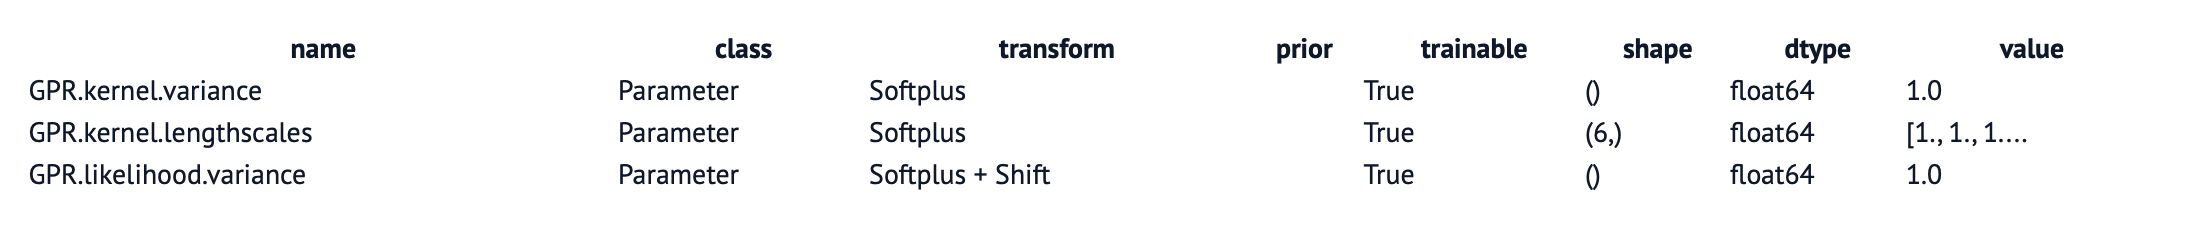

In [ ]:
def build_model(X, Y):
    kernel = gpflow.kernels.Matern52(
        lengthscales = [1.0] * X.shape[1]  # ARD: one length-scale per dimension
    )
    likelihood = gpflow.likelihoods.Gaussian()

    gpr = gpflow.models.GPR(
        data       = (X, Y),
        kernel     = kernel,
        likelihood = likelihood
    )

    gpflow.utilities.print_summary(gpr, fmt="notebook")
    return GaussianProcessRegression(gpr)

bayes_opt_model = build_model(design_matrix, output_vals)

# Initialise Ask-Tell Optimiser

In [ ]:
initial_data = trieste.data.Dataset(
    query_points = design_matrix,
    observations = output_vals
)

ask_tell = trieste.ask_tell_optimization.AskTellOptimizer(
    search_space     = search_space,
    datasets         = initial_data,
    models           = bayes_opt_model,
    acquisition_rule = trieste.acquisition.rule.EfficientGlobalOptimization(
        optimizer = trieste.acquisition.optimizer.generate_continuous_optimizer(
            num_optimization_runs = 500 #5000
        )
    )
)

# Bayesian Optimisation Loop

At each iteration:
1. **Ask** Trieste for the next point to evaluate.
2. **Convert** from the reverse parameterisation to $(n, \{l_k, u_k\})$.
3. **Evaluate** the objective — no monotonicity check needed.
4. **Tell** Trieste the result.

Note: every proposal is structurally valid by construction.

In [ ]:
num_repeats    = 500 #1000
when_to_print  = 50

for _i in range(num_repeats):

    # ask for next point in reverse parameterisation space
    x_new = ask_tell.ask()

    # evaluate objective — no monotonicity check, no rejection
    new_x, new_y = objective(
        params       = x_new,
        mu           = mu,
        target_power = target_power,
        target_alpha = target_alpha,
        K            = num_analyses
    )

    new_data = trieste.data.Dataset(
        query_points = new_x,
        observations = new_y
    )

    ask_tell.tell(new_data = new_data)

    if (_i + 1) % when_to_print == 0:
        print(f"\nLoop {_i+1} completed.", end="")
    elif (_i > when_to_print) and ((_i + 1) % 5 == 0):
        print(".", end="")

print("\nOptimisation complete.")


Loop 50 completed...

2026-04-03 18:10:36.082496: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.


.......
Loop 100 completed..........
Loop 150 completed..........

2026-04-03 18:16:05.795630: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-04-03 18:16:06.508171: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.



Loop 200 completed.

.........
Loop 250 completed..........
Loop 300 completed..........
Loop 350 completed..........
Loop 400 completed..........
Loop 450 completed..........
Loop 500 completed.
Optimisation complete.


# Results

In [ ]:
final_dataset = ask_tell.to_result().try_get_final_dataset()

# find best observed point
best_idx    = int(np.argmin(final_dataset.observations.numpy()))
best_params = final_dataset.query_points.numpy()[best_idx]
best_obj    = float(final_dataset.observations.numpy()[best_idx])

best_n, best_upper, best_lower = reverse_to_boundaries(best_params, num_analyses)

print(f"Best objective value: {best_obj:.4f}")
print(f"n per arm per stage:  {best_n:.2f}")
print(f"Upper boundaries:     {np.round(best_upper, 4)}")
print(f"Lower boundaries:     {np.round(best_lower, 4)}")

/tmp/marimo_355/__marimo__cell_AjVT_.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  best_obj    = float(final_dataset.observations.numpy()[best_idx])


Best objective value: 0.2681
n per arm per stage:  21.27
Upper boundaries:     [1.9876 1.9328 1.7663]
Lower boundaries:     [0.1293 1.0834 1.7663]


## Verify best design against triangular benchmark

In [ ]:
result_trial = sim.group_sequential_designs(
    n_analyses      = num_analyses,
    upper_bounds    = best_upper,
    lower_bounds    = best_lower,
    n_patients      = best_n,
    null_hypothesis = 0,
    alt_hypothesis  = delta1,
    variance        = sigma2
)

print(f"Achieved alpha':  {result_trial[1]:.4f}  (target <= {target_alpha})")
print(f"Achieved power':  {result_trial[2]:.4f}  (target >= {target_power})")
print()
print("Triangular benchmark:")
print(f"  Upper: [2.1196, 1.8735, 1.8356]")
print(f"  Lower: [0.0000, 1.1241, 1.8356]")
print(f"  n:     ~22")

Achieved alpha':  0.0555  (target <= 0.05)
Achieved power':  0.9004  (target >= 0.9)

Triangular benchmark:
  Upper: [2.1196, 1.8735, 1.8356]
  Lower: [0.0000, 1.1241, 1.8356]
  n:     ~22


## Plot objective function history

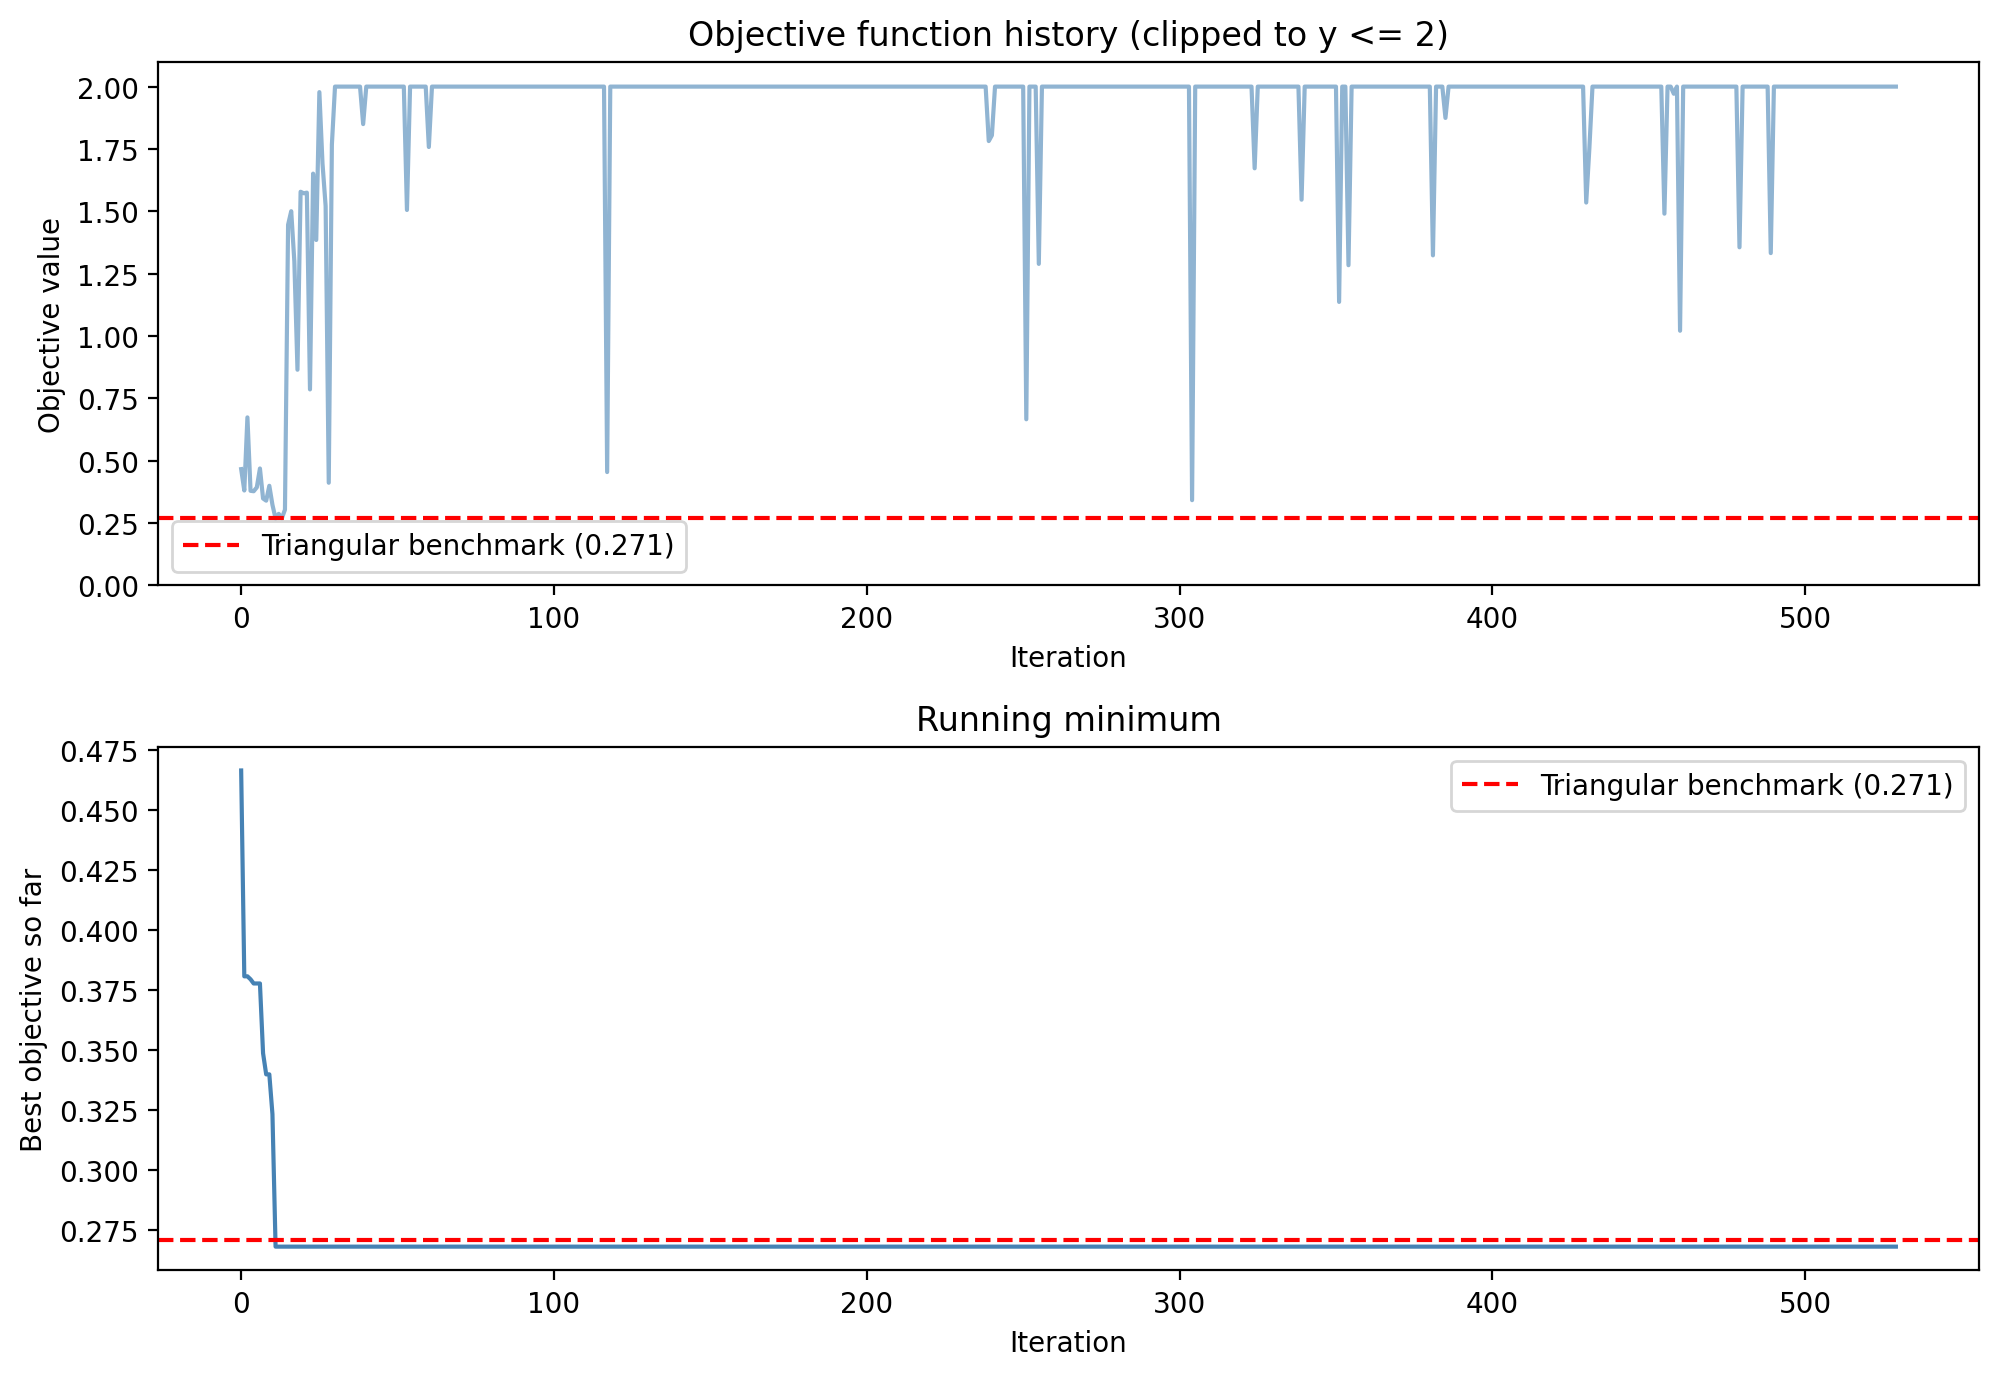

In [ ]:
_obs = final_dataset.observations.numpy().flatten()
_running_min = np.minimum.accumulate(_obs)

_fig, _axes = plt.subplots(nrows=2, figsize=(10, 7))

# top panel: raw history clipped to sensible range
_axes[0].plot(_obs, alpha=0.6, color="steelblue")
_axes[0].axhline(y=0.271, color="red", linestyle="--",
                 label="Triangular benchmark (0.271)")
_axes[0].set_ylim(0, 2.1)
_axes[0].set_xlabel("Iteration")
_axes[0].set_ylabel("Objective value")
_axes[0].set_title("Objective function history (clipped to y <= 2)")
_axes[0].legend()

# bottom panel: running minimum
_axes[1].plot(_running_min, color="steelblue")
_axes[1].axhline(y=0.271, color="red", linestyle="--",
                 label="Triangular benchmark (0.271)")
_axes[1].set_xlabel("Iteration")
_axes[1].set_ylabel("Best objective so far")
_axes[1].set_title("Running minimum")
_axes[1].legend()

_fig.tight_layout()
_fig

## Plot best design boundaries

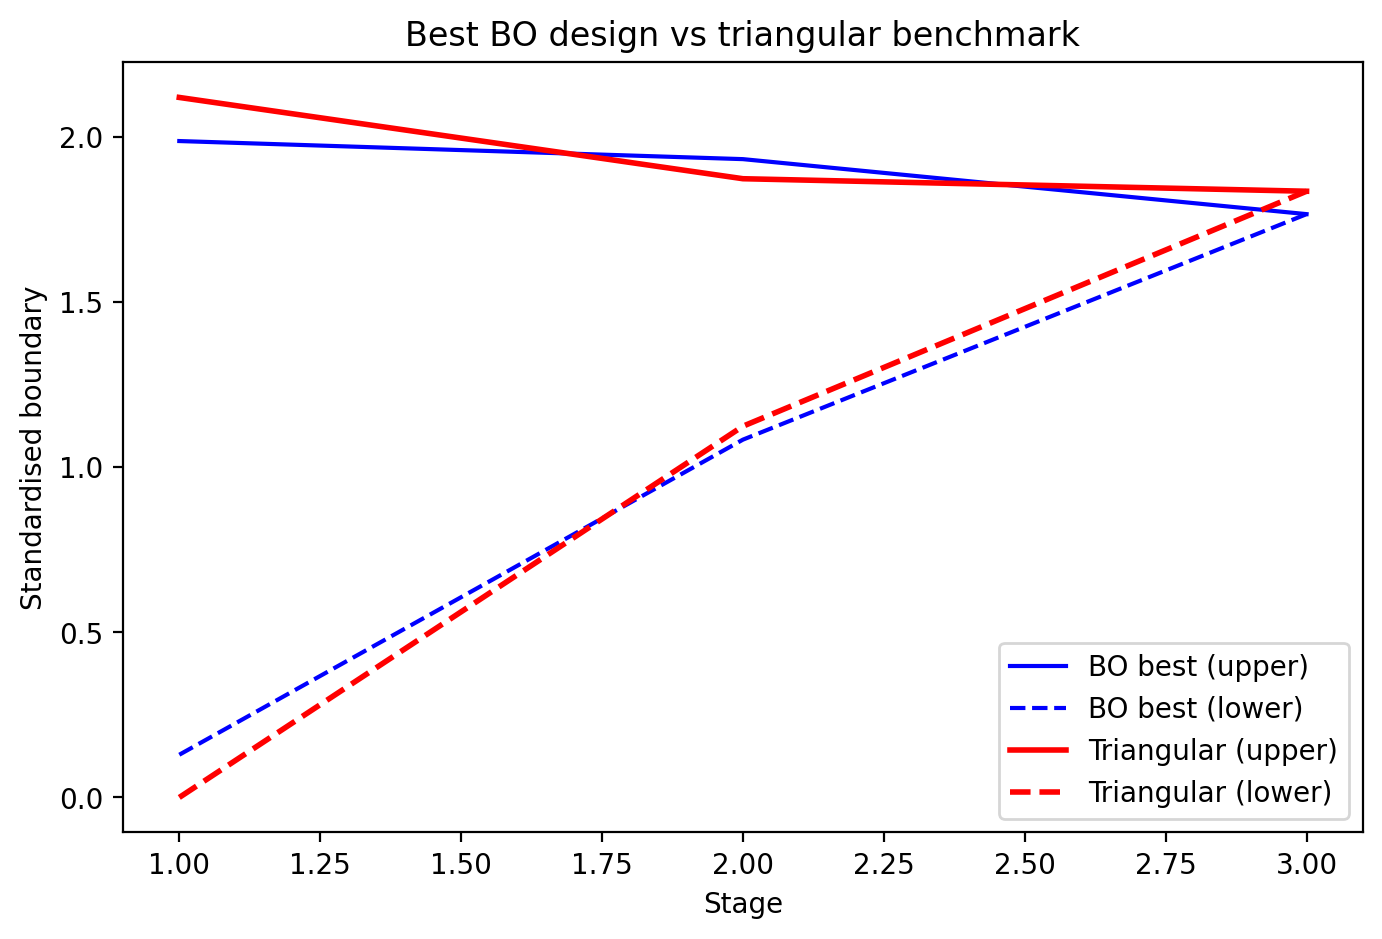

In [ ]:
_fig, _ax = plt.subplots(figsize=(8, 5))

# best BO design
_ax.plot([1, 2, 3], best_upper, color="blue", label="BO best (upper)")
_ax.plot([1, 2, 3], np.concatenate((best_lower[:2], [best_upper[2]])),
         color="blue", linestyle="--", label="BO best (lower)")

# triangular benchmark
_ax.plot([1, 2, 3], [2.1196, 1.8735, 1.8356], color="red",
         linewidth=2, label="Triangular (upper)")
_ax.plot([1, 2, 3], [0.0, 1.1241, 1.8356], color="red",
         linewidth=2, linestyle="--", label="Triangular (lower)")

_ax.set_xlabel("Stage")
_ax.set_ylabel("Standardised boundary")
_ax.set_title("Best BO design vs triangular benchmark")
_ax.legend()
_fig

# Save Results

In [ ]:
_data = ask_tell.to_result().try_get_final_dataset()

bounds_df = pd.DataFrame(
    data    = _data.query_points.numpy(),
    columns = ["n", "c", "delta_u3", "delta_l3", "delta_u2", "delta_l2"]
)
penalty_df = pd.DataFrame(
    data    = _data.observations.numpy(),
    columns = ["obj_f"]
)

results_df = pd.concat([bounds_df, penalty_df], axis=1)
results_df.to_csv("/tf/paul/reverse_param_results.csv", index=False)
print(f"Saved {results_df.shape[0]} rows.")
print(results_df.describe())

Saved 530 rows.
                n           c    delta_u3    delta_l3    delta_u2    delta_l2  \
count  530.000000  530.000000  530.000000  530.000000  530.000000  530.000000   
mean    78.132741    1.778909    1.929025    2.027516    1.921490    1.905491   
std     54.543000    1.800373    1.359284    1.298135    1.260862    1.358609   
min      2.000000   -1.164392    0.000000    0.000000    0.000000    0.000000   
25%     24.802553    0.313197    0.628268    0.881747    0.843073    0.699851   
50%     77.385680    1.766784    1.878545    2.007266    1.825261    1.788373   
75%    129.833743    3.223205    3.236160    3.239647    3.058584    3.100788   
max    154.149252    4.835608    3.999546    4.000000    4.000000    4.000000   

            obj_f  
count  530.000000  
mean     1.912177  
std      0.323847  
min      0.268146  
25%      2.000000  
50%      2.000000  
75%      2.000000  
max      2.000000  
